<a href="https://colab.research.google.com/github/Leandro2402-bit/Procesamiento-Digital-Imagenes/blob/main/Proyecto_Final/melanoma_clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Clasificación de Lesiones Cutáneas con EfficientNet-B3
### Procesamiento Digital de Imágenes

**Dataset:** melanoma-b2rp6 (Roboflow / ISIC)  
**Clases:** `benign` · `malignant` · `non-melanoma`  
**Modelo:** EfficientNet-B3 con Transfer Learning  
**Entorno:** Google Colab — GPU T4

**Link:** [Dataset en Roboflow](https://app.roboflow.com/robox-b7rra/melanoma-b2rp6-oa0tf/browse?queryText=&pageSize=50&startingIndex=0&browseQuery=true)

---
---

### Cambios en esta versión (v2)
- **Augmentation reforzado**: `RandomResizedCrop`, `RandomPerspective`, mayor rango de rotación y color.
- **`WeightedRandomSampler`**: balancea la frecuencia con la que el modelo ve cada clase por época (no solo la pérdida).
- **`CrossEntropyLoss` sin `class_weights`**: el balanceo ahora lo aporta el sampler, evitando doble compensación.


##Celda 1 — Instalación de dependencias
Instalar las librerías que no vienen por defecto en Colab.

In [ ]:
# Roboflow: para descargar el dataset directamente desde Roboflow Universe
!pip install roboflow -q

# scikit-learn: para métricas avanzadas (F1, AUC-ROC, matriz de confusión)
!pip install scikit-learn -q

# timm: librería de modelos de visión con pesos preentrenados (alternativa si torchvision falla)
!pip install timm -q

print("✅ Instalación completa")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 70.4 MB/s eta 0:00:00
✅ Instalación completa


##Celda 2 — Importación de librerías
Todos los imports en un solo lugar para facilitar la lectura y depuración.

In [ ]:
# ── Sistema y utilidades ──────────────────────────────────────────────────────
import os
import shutil
import random
import warnings
warnings.filterwarnings('ignore')

# ── Manejo de datos y álgebra ─────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── PyTorch: framework principal de deep learning ─────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, ConcatDataset, WeightedRandomSampler

# ── Torchvision: modelos preentrenados y transformaciones de imagen ───────────
import torchvision
import torchvision.transforms as transforms
from torchvision import models, datasets

# ── PIL: carga y manipulación de imágenes ────────────────────────────────────
from PIL import Image

# ── Scikit-learn: métricas de evaluación ─────────────────────────────────────
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize

# ── Roboflow: descarga del dataset ────────────────────────────────────────────
from roboflow import Roboflow

# ── Configuración de reproducibilidad ────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# ── Verificar disponibilidad de GPU ──────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Librerías cargadas correctamente")
print(f"🖥️  Dispositivo de entrenamiento: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memoria disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✅ Librerías cargadas correctamente
🖥️  Dispositivo de entrenamiento: cuda
   GPU: Tesla T4
   Memoria disponible: 15.6 GB


##Celda 3 — Descarga del dataset desde Roboflow

In [ ]:
# Conectar con la API de Roboflow usando la clave del proyecto
rf = Roboflow(api_key="V0ZwzUEZsNVJziKrOwjf")

# Acceder al workspace y proyecto específico
project = rf.workspace("robox-b7rra").project("melanoma-b2rp6-oa0tf")

# Descargar versión 1 en formato 'folder' (estructura: train/valid/test con subcarpetas por clase)
version = project.version(1)
dataset = version.download("folder")

# Guardar la ruta base del dataset descargado
DATASET_PATH = dataset.location
print(f"\n📁 Dataset descargado en: {DATASET_PATH}")

# Verificar la estructura de carpetas
for split in ['train', 'valid', 'test']:
    split_path = os.path.join(DATASET_PATH, split)
    if os.path.exists(split_path):
        clases = os.listdir(split_path)
        total = sum(len(os.listdir(os.path.join(split_path, c))) for c in clases if os.path.isdir(os.path.join(split_path, c)))
        print(f"   {split:10s}: {total:5d} imágenes | clases: {clases}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to melanoma-1 in folder:: 100%|██████████| 9360/9360 [00:01<00:00, 9250.31it/s]


📁 Dataset descargado en: /content/melanoma-1
   train     :  7817 imágenes | clases: ['non-melanoma', 'malignant', 'benign']
   valid     :  1167 imágenes | clases: ['malignant', 'benign']
   test      :   374 imágenes | clases: ['malignant', 'benign']


##Celda 4 — Redistribución del dataset (70 / 15 / 15)

La partición original del dataset es **84% train / 12% valid / 4% test**.  
El conjunto de test con solo 375 imágenes es insuficiente para evaluar de forma robusta un clasificador de 3 clases.  
Entonces se redistribuye a **70% train / 15% valid / 15% test** combinando todos los splits originales y repartiendo manualmente, manteniendo la proporción de clases.

In [ ]:
import glob
from sklearn.model_selection import train_test_split

# ── Recolectar todas las imágenes con su etiqueta ────────────────────────────
all_images = []  # lista de (ruta_imagen, nombre_clase)
CLASES = ['benign', 'malignant', 'non-melanoma']

for split in ['train', 'valid', 'test']:
    for clase in CLASES:
        clase_path = os.path.join(DATASET_PATH, split, clase)
        if not os.path.exists(clase_path):
            continue
        imagenes = glob.glob(os.path.join(clase_path, '*.jpg')) + \
                   glob.glob(os.path.join(clase_path, '*.png')) + \
                   glob.glob(os.path.join(clase_path, '*.jpeg'))
        for img in imagenes:
            all_images.append((img, clase))

# Convertir a arrays para stratified split
rutas   = [x[0] for x in all_images]
etiquetas = [x[1] for x in all_images]
print(f"Total imágenes encontradas: {len(all_images)}")

# ── Split estratificado: 70% train — 30% temp ─────────────────────────────────
train_r, temp_r, train_e, temp_e = train_test_split(
    rutas, etiquetas, test_size=0.30, stratify=etiquetas, random_state=SEED
)

# ── Split del 30% temp: 50% valid — 50% test → 15% y 15% del total ───────────
val_r, test_r, val_e, test_e = train_test_split(
    temp_r, temp_e, test_size=0.50, stratify=temp_e, random_state=SEED
)

# ── Copiar imágenes a nueva estructura de carpetas ────────────────────────────
NEW_DATASET_PATH = '/content/melanoma_split'

def copiar_split(rutas, etiquetas, split_name):
    for ruta, clase in zip(rutas, etiquetas):
        destino_dir = os.path.join(NEW_DATASET_PATH, split_name, clase)
        os.makedirs(destino_dir, exist_ok=True)
        shutil.copy2(ruta, destino_dir)

print("\nCopiando imágenes a nueva estructura...")
copiar_split(train_r, train_e, 'train')
copiar_split(val_r,   val_e,   'valid')
copiar_split(test_r,  test_e,  'test')

# ── Verificar nueva distribución ─────────────────────────────────────────────
print("\n📊 Nueva distribución del dataset:")
print(f"{'Split':<10} {'Total':>7}  {'benign':>8} {'malignant':>10} {'non-melanoma':>13}")
print("-" * 52)
for split in ['train', 'valid', 'test']:
    counts = {}
    for clase in CLASES:
        p = os.path.join(NEW_DATASET_PATH, split, clase)
        counts[clase] = len(os.listdir(p)) if os.path.exists(p) else 0
    total = sum(counts.values())
    print(f"{split:<10} {total:>7}  {counts['benign']:>8} {counts['malignant']:>10} {counts['non-melanoma']:>13}")

DATASET_PATH = NEW_DATASET_PATH
print("\n✅ Dataset redistribuido correctamente (70/15/15)")

Total imágenes encontradas: 9358

Copiando imágenes a nueva estructura...

📊 Nueva distribución del dataset:
Split        Total    benign  malignant  non-melanoma
----------------------------------------------------
train         6550      3029       3109           412
valid         1404       649        666            89
test          1404       650        666            88

✅ Dataset redistribuido correctamente (70/15/15)


##Celda 5 — Exploración y visualización del dataset

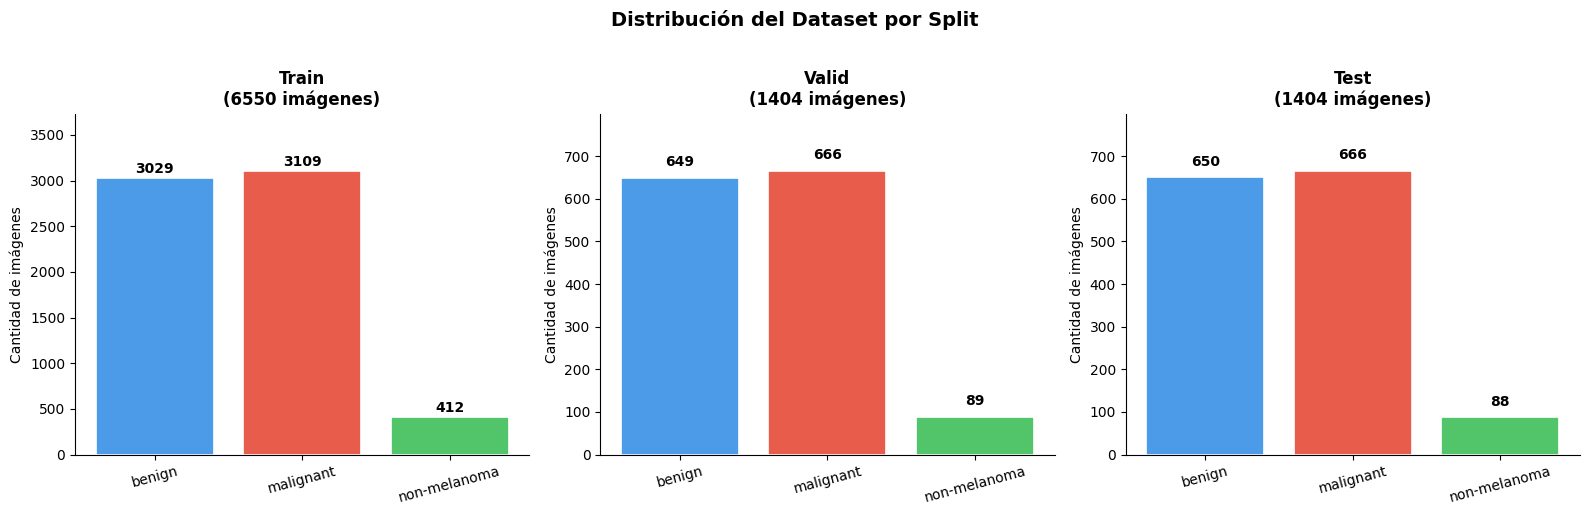

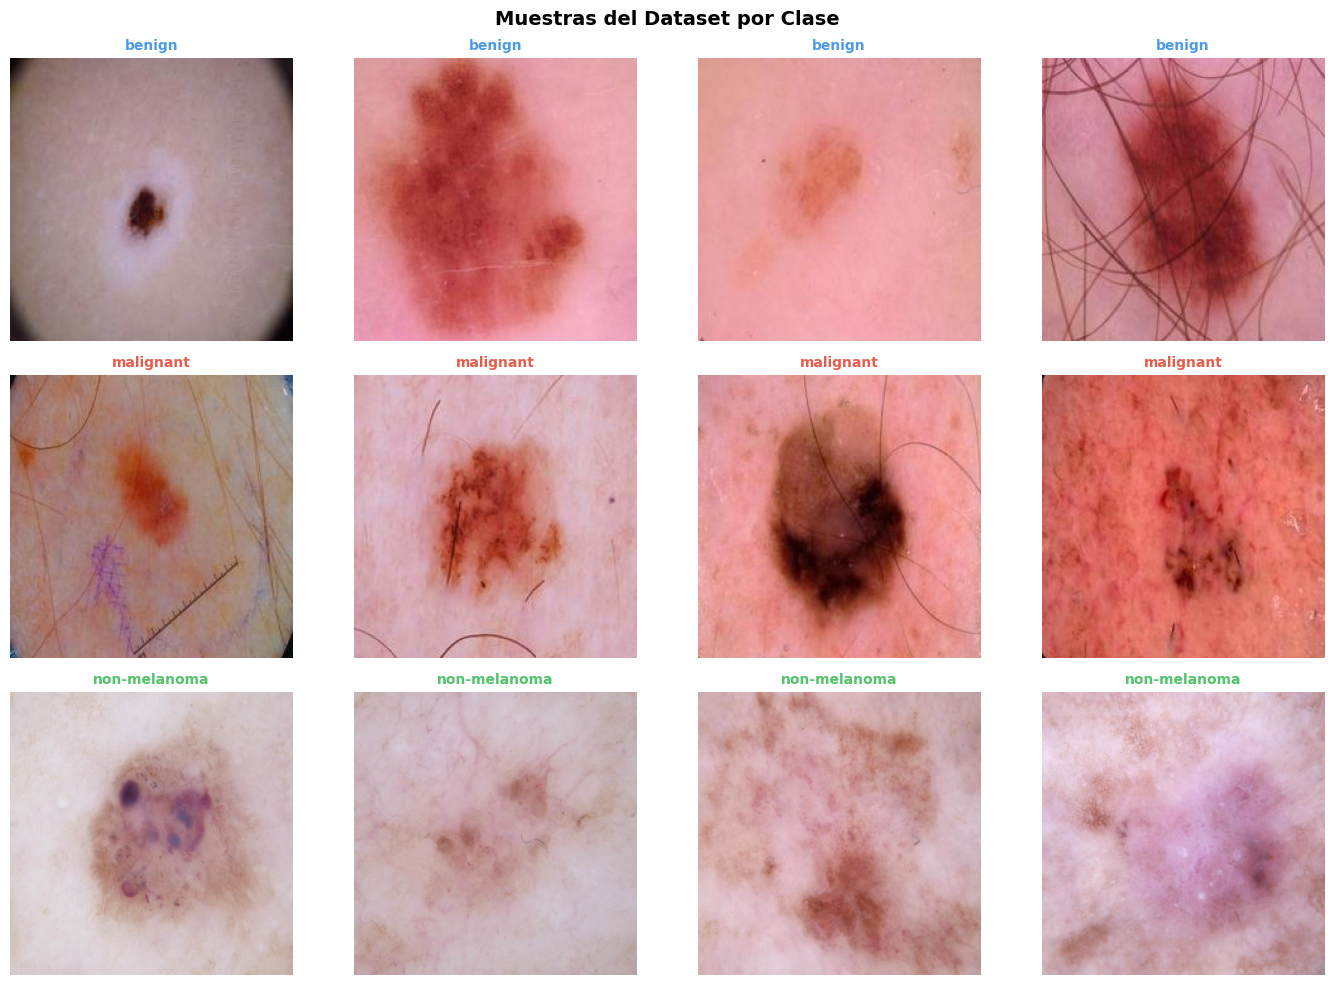

✅ Visualización completa


In [ ]:
# ── Contar imágenes por clase y split ────────────────────────────────────────
conteo = {}
for split in ['train', 'valid', 'test']:
    conteo[split] = {}
    for clase in CLASES:
        p = os.path.join(DATASET_PATH, split, clase)
        conteo[split][clase] = len(os.listdir(p)) if os.path.exists(p) else 0

df_conteo = pd.DataFrame(conteo).T

# ── Figura 1: Distribución de clases por split ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribución del Dataset por Split', fontsize=14, fontweight='bold', y=1.02)
colores = ['#4C9BE8', '#E85C4C', '#52C46A']

for ax, split in zip(axes, ['train', 'valid', 'test']):
    valores = [conteo[split][c] for c in CLASES]
    barras = ax.bar(CLASES, valores, color=colores, edgecolor='white', linewidth=1.2)
    ax.set_title(f'{split.capitalize()}\n({sum(valores)} imágenes)', fontweight='bold')
    ax.set_ylabel('Cantidad de imágenes')
    ax.set_ylim(0, max(valores) * 1.2)
    # Añadir etiquetas encima de cada barra
    for barra, val in zip(barras, valores):
        ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 20,
                str(val), ha='center', va='bottom', fontweight='bold')
    ax.set_xticklabels(CLASES, rotation=15)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/content/distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figura 2: Muestras visuales del dataset ──────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Muestras del Dataset por Clase', fontsize=14, fontweight='bold')

for i, clase in enumerate(CLASES):
    clase_path = os.path.join(DATASET_PATH, 'train', clase)
    imagenes = random.sample(os.listdir(clase_path), min(4, len(os.listdir(clase_path))))
    for j, img_name in enumerate(imagenes):
        img = Image.open(os.path.join(clase_path, img_name)).convert('RGB')
        axes[i][j].imshow(img)
        axes[i][j].set_title(clase, fontsize=10, color=colores[i], fontweight='bold')
        axes[i][j].axis('off')

plt.tight_layout()
plt.savefig('/content/muestras_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualización completa")

##Celda 6 — Preprocesamiento y DataLoaders

Se aplican transformaciones distintas para train (con augmentation) y para valid/test (solo normalización).  
La normalización usa las estadísticas de ImageNet porque EfficientNet-B3 fue preentrenado en ese dataset.

- Augmentation más agresivo (`RandomResizedCrop`, `RandomPerspective`, rotación ±30°, color más variable) para que las repeticiones de imágenes minoritarias no luzcan idénticas.
- `WeightedRandomSampler`: en promedio, cada clase es muestreada con la misma frecuencia por época, sin importar cuántas imágenes tenga originalmente.

In [ ]:
# ── Tamaño de entrada requerido por EfficientNet-B3 ───────────────────────────
IMG_SIZE = 300  # EfficientNet-B3 fue diseñado para imágenes de 300x300

# Media y desviación estándar de ImageNet (requerido para transfer learning)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Transformaciones para entrenamiento (con augmentation reforzado) ──────────
# Se añaden RandomResizedCrop y RandomPerspective, y se amplía rotación/color
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),     # recorte + zoom aleatorio
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),                        # antes: 20°
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),    # nuevo: distorsión de perspectiva
    transforms.ColorJitter(
        brightness=0.3, contrast=0.3,                             # antes: 0.2
        saturation=0.2, hue=0.05
    ),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# ── Transformaciones para validación y test (sin cambios) ────────────────────
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# ── Crear datasets de PyTorch usando ImageFolder ──────────────────────────────
train_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, 'train'), transform=train_transforms)
val_dataset   = datasets.ImageFolder(os.path.join(DATASET_PATH, 'valid'), transform=eval_transforms)
test_dataset  = datasets.ImageFolder(os.path.join(DATASET_PATH, 'test'),  transform=eval_transforms)

# Verificar que el mapeo de clases sea correcto
CLASS_TO_IDX = train_dataset.class_to_idx
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
print(f"Mapeo de clases: {CLASS_TO_IDX}")

# ── Pesos de clase ─────────────────────
#Se usan para construir los pesos de muestreo del WeightedRandomSampler.
etiquetas_train = [label for _, label in train_dataset.samples]
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=etiquetas_train
)
print(f"\nPesos de referencia por clase (balanced):")
for clase, peso in zip(CLASES, class_weights):
    print(f"   {clase:<15}: {peso:.4f}")

# ══════════════════════════════════════════════════════════════════════════════
# WeightedRandomSampler
# ══════════════════════════════════════════════════════════════════════════════
# A cada imagen se le asigna como peso de muestreo el class_weight de su clase.
# Con num_samples = len(dataset) y replacement=True, esto hace que, en promedio,
# las 3 clases se muestreen con la MISMA frecuencia por época:
sample_weights = [class_weights[label] for label in etiquetas_train]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# ── Crear DataLoaders ─────────────────────────────────────────────────────────
BATCH_SIZE = 32  # 32 es óptimo para GPU T4 con EfficientNet-B3

# Importante: al usar 'sampler', NO se debe usar shuffle=True (son excluyentes)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"\n✅ DataLoaders creados (train con WeightedRandomSampler balanceado)")
print(f"   Train:      {len(train_dataset):>5} imágenes | {len(train_loader):>4} batches")
print(f"   Validación: {len(val_dataset):>5} imágenes | {len(val_loader):>4} batches")
print(f"   Test:       {len(test_dataset):>5} imágenes | {len(test_loader):>4} batches")


Mapeo de clases: {'benign': 0, 'malignant': 1, 'non-melanoma': 2}

Pesos de referencia por clase (balanced):
   benign         : 0.7208
   malignant      : 0.7023
   non-melanoma   : 5.2994

✅ DataLoaders creados (train con WeightedRandomSampler balanceado)
   Train:       6550 imágenes |  205 batches
   Validación:  1404 imágenes |   44 batches
   Test:        1404 imágenes |   44 batches


##Celda 7 — Definición del modelo: EfficientNet-B3

**¿Por qué EfficientNet-B3 y no otro?**

| Modelo | Params | Top-1 ImageNet | Adecuado para T4 |
|---|---|---|---|
| ResNet-50 | 25M | 76.1% | ✅ |
| VGG-16 | 138M | 71.6% | ⚠️ lento |
| EfficientNet-B0 | 5.3M | 77.1% | ✅ (ligero) |
| **EfficientNet-B3** | **12M** | **81.6%** | **✅ óptimo** |
| EfficientNet-B7 | 66M | 84.3% | ❌ en T4 |

EfficientNet-B3 escala de forma balanceada profundidad, ancho y resolución, logrando mayor accuracy que ResNet-50 con la mitad de parámetros. Es ideal para imágenes médicas con GPU limitada.

In [ ]:
NUM_CLASSES = 3

# ── Cargar EfficientNet-B3 preentrenado en ImageNet ───────────────────────────
model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)

# ── Fase 1: Congelar TODAS las capas base ────────────────────────────────────
# Solo entrenamos la cabeza de clasificación en las primeras épocas.
# Esto evita que los pesos de ImageNet se destruyan al inicio del entrenamiento.
for param in model.parameters():
    param.requires_grad = False

# ── Reemplazar la cabeza de clasificación original ────────────────────────────
# EfficientNet-B3 tiene 1536 features de salida antes del clasificador
in_features = model.classifier[1].in_features  # 1536

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),    # Dropout para regularización
    nn.Linear(in_features, 256),        # Capa intermedia para aprendizaje específico del dominio
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(256, NUM_CLASSES)         # Salida: 3 clases (benign, malignant, non-melanoma)
)

model = model.to(DEVICE)

# ── Resumen del modelo ────────────────────────────────────────────────────────
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"📐 Arquitectura: EfficientNet-B3")
print(f"   Parámetros totales:     {total_params:>12,}")
print(f"   Parámetros entrenables: {trainable_params:>12,}  (solo la cabeza en Fase 1)")
print(f"   Porcentaje congelado:   {(1 - trainable_params/total_params)*100:.1f}%")
print(f"\n✅ Modelo listo en: {DEVICE}")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 124MB/s]


📐 Arquitectura: EfficientNet-B3
   Parámetros totales:       11,090,475
   Parámetros entrenables:      394,243  (solo la cabeza en Fase 1)
   Porcentaje congelado:   96.4%

✅ Modelo listo en: cuda


##Celda 8 — Hiperparámetros y función de pérdida

**Función de pérdida (v2):** `CrossEntropyLoss` **sin** pesos por clase.  
El balanceo de clases ahora lo realiza el `WeightedRandomSampler` de la Celda 6, que ya expone al modelo a una distribución equilibrada. Aplicar `class_weights` aquí además del sampler sobre-corregiría hacia `non-melanoma`, perjudicando la precisión de `benign` y `malignant`.

**Estrategia de dos fases**
- **Fase 1 (épocas 1–10):** solo se entrena la cabeza. LR alto → convergencia rápida.
- **Fase 2 (épocas 11–25):** se descongelan las últimas capas del backbone para fine-tuning. LR bajo → ajuste fino sin destruir los pesos preentrenados.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# HIPERPARÁMETROS — todos en un solo lugar para facilitar experimentación
# ══════════════════════════════════════════════════════════════════════════════

# Número de épocas por fase
EPOCHS_FASE1 = 10   # Entrenamiento de la cabeza (capas base congeladas)
EPOCHS_FASE2 = 15   # Fine-tuning de capas superiores del backbone
EPOCHS_TOTAL = EPOCHS_FASE1 + EPOCHS_FASE2

# Tasas de aprendizaje
LR_FASE1 = 1e-3     # LR alto: la cabeza empieza desde cero, necesita pasos grandes
LR_FASE2 = 1e-4     # LR bajo: el backbone ya tiene buenos pesos, ajuste fino delicado

# Regularización L2 (weight decay): penaliza pesos muy grandes para evitar sobreajuste
WEIGHT_DECAY = 1e-4

# ── Función de pérdida (v2) ────────────────────────────────────────────────
# CrossEntropyLoss SIN class_weights: el balanceo de clases ya lo realiza el
# WeightedRandomSampler (Celda 6). Sumar class_weights aquí ADEMÁS del sampler
# sobre-corregiría hacia 'non-melanoma'.
criterion = nn.CrossEntropyLoss()

# ── Optimizador Fase 1: solo parámetros de la cabeza ─────────────────────────
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_FASE1,
    weight_decay=WEIGHT_DECAY
)

# ── Scheduler: reduce la LR si la validación se estanca ──────────────────────
# Después de 3 épocas sin mejora, multiplica la LR por 0.3
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.3, patience=3
)

print("⚙️  Hiperparámetros configurados:")
print(f"   Batch size:          {BATCH_SIZE}")
print(f"   Épocas Fase 1:       {EPOCHS_FASE1}  (LR={LR_FASE1})")
print(f"   Épocas Fase 2:       {EPOCHS_FASE2}  (LR={LR_FASE2})")
print(f"   Weight decay:        {WEIGHT_DECAY}")
print(f"   Función de pérdida:  CrossEntropyLoss (sin pesos; balanceo vía sampler)")
print(f"   Optimizador:         Adam")
print(f"   Scheduler:           ReduceLROnPlateau (patience=3, factor=0.3)")


⚙️  Hiperparámetros configurados:
   Batch size:          32
   Épocas Fase 1:       10  (LR=0.001)
   Épocas Fase 2:       15  (LR=0.0001)
   Weight decay:        0.0001
   Función de pérdida:  CrossEntropyLoss (sin pesos; balanceo vía sampler)
   Optimizador:         Adam
   Scheduler:           ReduceLROnPlateau (patience=3, factor=0.3)


##Celda 9 — Loop de entrenamiento (Fase 1 + Fase 2)

In [ ]:
# ── Función auxiliar: una época de entrenamiento ──────────────────────────────
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()          # Limpiar gradientes del batch anterior
        outputs = model(images)        # Forward pass
        loss = criterion(outputs, labels)  # Calcular pérdida
        loss.backward()                # Backward pass (calcular gradientes)
        optimizer.step()               # Actualizar pesos

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    return running_loss / total, correct / total


# ── Función auxiliar: evaluación en validación ────────────────────────────────
def eval_epoch(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():  # No calcular gradientes en evaluación
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)

    return running_loss / total, correct / total


# ── Historial para graficar después ──────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
BEST_MODEL_PATH = '/content/best_model.pth'

print("=" * 65)
print(f"{'FASE 1: Entrenamiento de la cabeza (backbone congelado)':^65}")
print("=" * 65)

for epoch in range(1, EPOCHS_TOTAL + 1):

    # ── Transición a Fase 2 ───────────────────────────────────────────────────
    if epoch == EPOCHS_FASE1 + 1:
        print("\n" + "=" * 65)
        print(f"{'FASE 2: Fine-tuning de capas superiores del backbone':^65}")
        print("=" * 65)

        # Descongelar los últimos 2 bloques del backbone de EfficientNet-B3
        for name, param in model.named_parameters():
            if 'features.7' in name or 'features.8' in name or 'classifier' in name:
                param.requires_grad = True

        # Nuevo optimizador con LR más bajo para fine-tuning
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=LR_FASE2,
            weight_decay=WEIGHT_DECAY
        )
        trainable_fase2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Parámetros entrenables en Fase 2: {trainable_fase2:,}\n")

    # ── Entrenamiento y evaluación de la época ────────────────────────────────
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = eval_epoch(model, val_loader,   criterion)

    # Ajustar LR si la val_loss no mejora
    scheduler.step(val_loss)

    # Guardar el mejor modelo basándose en val_loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        mejor_marker = " ← ✅ mejor"
    else:
        mejor_marker = ""

    # Guardar historial
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    fase = "F1" if epoch <= EPOCHS_FASE1 else "F2"
    print(f"[{fase}] Época {epoch:>2}/{EPOCHS_TOTAL} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.3f}{mejor_marker}")

print(f"\n✅ Entrenamiento finalizado. Mejor val_loss: {best_val_loss:.4f}")
print(f"   Modelo guardado en: {BEST_MODEL_PATH}")

     FASE 1: Entrenamiento de la cabeza (backbone congelado)     
[F1] Época  1/25 | Train Loss: 0.5527 Acc: 0.770 | Val Loss: 0.5111 Acc: 0.788 ← ✅ mejor
[F1] Época  2/25 | Train Loss: 0.4600 Acc: 0.804 | Val Loss: 0.4680 Acc: 0.796 ← ✅ mejor
[F1] Época  3/25 | Train Loss: 0.4186 Acc: 0.819 | Val Loss: 0.3992 Acc: 0.815 ← ✅ mejor
[F1] Época  4/25 | Train Loss: 0.4197 Acc: 0.822 | Val Loss: 0.4236 Acc: 0.808
[F1] Época  5/25 | Train Loss: 0.3885 Acc: 0.833 | Val Loss: 0.3898 Acc: 0.808 ← ✅ mejor
[F1] Época  6/25 | Train Loss: 0.4043 Acc: 0.819 | Val Loss: 0.4128 Acc: 0.811
[F1] Época  7/25 | Train Loss: 0.3994 Acc: 0.827 | Val Loss: 0.3684 Acc: 0.834 ← ✅ mejor
[F1] Época  8/25 | Train Loss: 0.3997 Acc: 0.823 | Val Loss: 0.3836 Acc: 0.828
[F1] Época  9/25 | Train Loss: 0.3703 Acc: 0.844 | Val Loss: 0.3742 Acc: 0.825
[F1] Época 10/25 | Train Loss: 0.3732 Acc: 0.843 | Val Loss: 0.3689 Acc: 0.828

      FASE 2: Fine-tuning de capas superiores del backbone       
Parámetros entrenables en F

##Celda 10 — Gráficas de entrenamiento

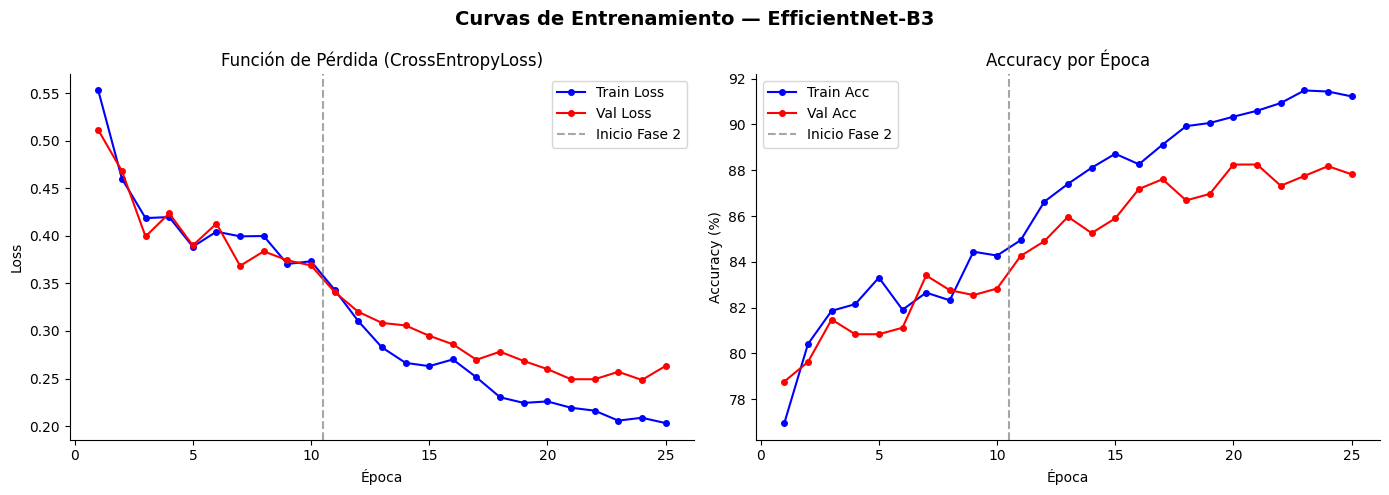

✅ Curvas guardadas


In [ ]:
epochs_range = range(1, EPOCHS_TOTAL + 1)
fase2_start = EPOCHS_FASE1 + 0.5  # línea vertical que marca el inicio de Fase 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de Entrenamiento — EfficientNet-B3', fontsize=14, fontweight='bold')

# ── Gráfica de Loss ───────────────────────────────────────────────────────────
axes[0].plot(epochs_range, history['train_loss'], 'b-o', markersize=4, label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   'r-o', markersize=4, label='Val Loss')
axes[0].axvline(x=fase2_start, color='gray', linestyle='--', alpha=0.7, label='Inicio Fase 2')
axes[0].set_title('Función de Pérdida (CrossEntropyLoss)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# ── Gráfica de Accuracy ───────────────────────────────────────────────────────
axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], 'b-o', markersize=4, label='Train Acc')
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   'r-o', markersize=4, label='Val Acc')
axes[1].axvline(x=fase2_start, color='gray', linestyle='--', alpha=0.7, label='Inicio Fase 2')
axes[1].set_title('Accuracy por Época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/content/curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Curvas guardadas")

##Celda 11 — Evaluación final en el conjunto de Test

In [ ]:
# ── Cargar el mejor modelo guardado durante el entrenamiento ──────────────────
model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)  # Probabilidades por clase

        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# ── Reporte de clasificación completo ────────────────────────────────────────
print("📋 Reporte de Clasificación en Test Set:")
print("=" * 60)
print(classification_report(all_labels, all_preds,
                             target_names=CLASES, digits=4))

# ── AUC-ROC multiclase (One-vs-Rest) ─────────────────────────────────────────
labels_bin = label_binarize(all_labels, classes=[0, 1, 2])
auc_scores = {}
for i, clase in enumerate(CLASES):
    auc_scores[clase] = roc_auc_score(labels_bin[:, i], all_probs[:, i])
    print(f"AUC-ROC {clase:<15}: {auc_scores[clase]:.4f}")

print(f"\nAUC-ROC macro promedio: {np.mean(list(auc_scores.values())):.4f}")

📋 Reporte de Clasificación en Test Set:
              precision    recall  f1-score   support

      benign     0.9117    0.8415    0.8752       650
   malignant     0.8479    0.9039    0.8750       666
non-melanoma     0.8830    0.9432    0.9121        88

    accuracy                         0.8775      1404
   macro avg     0.8808    0.8962    0.8874      1404
weighted avg     0.8796    0.8775    0.8774      1404

AUC-ROC benign         : 0.9640
AUC-ROC malignant      : 0.9553
AUC-ROC non-melanoma   : 0.9984

AUC-ROC macro promedio: 0.9726


##Celda 12 — Matriz de confusión y curvas ROC

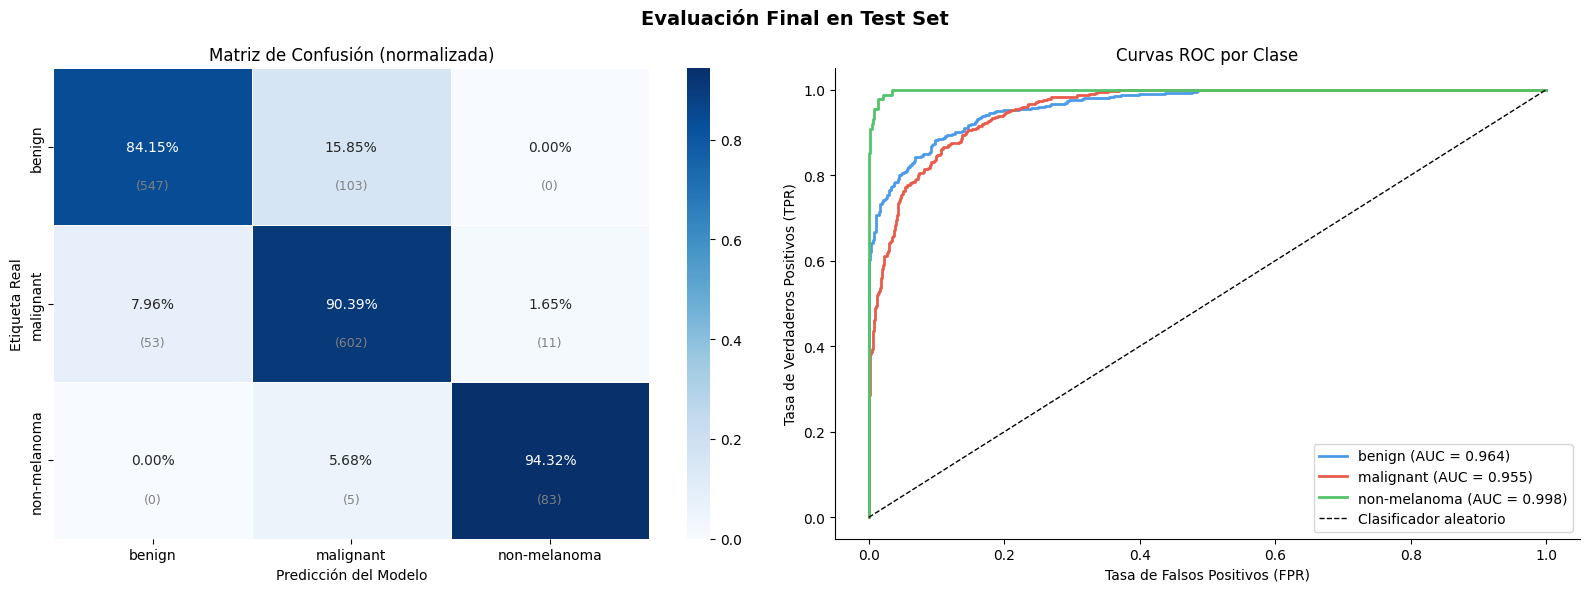

✅ Gráficas de evaluación guardadas


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Evaluación Final en Test Set', fontsize=14, fontweight='bold')

# ── Matriz de confusión ───────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalizada por fila

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=CLASES, yticklabels=CLASES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Matriz de Confusión (normalizada)')
axes[0].set_ylabel('Etiqueta Real')
axes[0].set_xlabel('Predicción del Modelo')

# Añadir conteos absolutos en cada celda
for i in range(len(CLASES)):
    for j in range(len(CLASES)):
        axes[0].text(j + 0.5, i + 0.75, f'({cm[i,j]})',
                     ha='center', va='center', fontsize=9, color='gray')

# ── Curvas ROC por clase ──────────────────────────────────────────────────────
colores_roc = ['#4C9BE8', '#E85C4C', '#52C46A']
for i, (clase, color) in enumerate(zip(CLASES, colores_roc)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, lw=2,
                 label=f'{clase} (AUC = {roc_auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
axes[1].set_title('Curvas ROC por Clase')
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].legend(loc='lower right')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/content/evaluacion_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráficas de evaluación guardadas")

##Celda 13 — Guardar modelo para Hugging Face

Se guarda el modelo en formato compatible con Hugging Face Spaces.

In [ ]:
import json

# ── Guardar pesos del modelo ──────────────────────────────────────────────────
torch.save(model.state_dict(), '/content/melanoma_efficientnet_b3.pth')

# ── Guardar configuración del modelo (necesaria para reconstruirlo en HF) ─────
config = {
    'arquitectura': 'efficientnet_b3',
    'num_classes': NUM_CLASSES,
    'clases': CLASES,
    'class_to_idx': CLASS_TO_IDX,
    'img_size': IMG_SIZE,
    'imagenet_mean': IMAGENET_MEAN,
    'imagenet_std': IMAGENET_STD
}

with open('/content/model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("✅ Archivos listos para Hugging Face:")
print("   📄 melanoma_efficientnet_b3.pth  — pesos del modelo")
print("   📄 model_config.json             — configuración y clases")
print("\nDescarga estos dos archivos desde el panel de archivos de Colab (📁 izquierda)")

✅ Archivos listos para Hugging Face:
   📄 melanoma_efficientnet_b3.pth  — pesos del modelo
   📄 model_config.json             — configuración y clases

Descarga estos dos archivos desde el panel de archivos de Colab (📁 izquierda)


**Link del panel interactivo:** [hugging face](https://huggingface.co/spaces/lezapatama/melanoma-classifier)